In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

In [3]:
print(f(5))

60


In [4]:
x_series = np.arange(1,15,2)

In [5]:
x_series

array([ 1,  3,  5,  7,  9, 11, 13])

In [6]:
y_series = f(x_series)

In [7]:
y_series

array([  4,  20,  60, 124, 212, 324, 460])

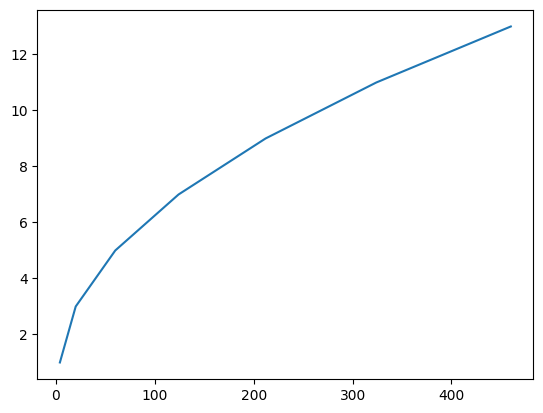

In [8]:
plt.plot(y_series,x_series)
plt.show()

In [9]:
x=3.0
h=0.000000000000001
(f(x+h)-f(x))/h

10.658141036401503

In [98]:
class Value:
    def __init__(self, data, _children=(), _op='',label=""):
        self.data = data
        self.grad = 0
        self.label = label 
        self.backward = lambda: None ## This is done so when we are initially creating the Value Object the backward value is not calculated
        # internal variables used for autograd graph construction
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
    
        def _backward():
            ## Derivate of (a+b) 
          self.grad += 1.0 * out.grad
          other.grad += 1.0 * out.grad
        out._backward = _backward
    
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
    
        def _backward():
            ##Derivate of a* b 
          self.grad += other.data * out.grad
          other.grad += self.data * out.grad
        out._backward = _backward
        return out
          
    def __truediv__(self, other): # self / other
        out = Value (self.data * other.data**-1,(self,other),'/')
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    ## Defining the intial backpropagation assuming in our given model the last operation is tanh. Assuming tanh = t, then the derivative of it is 1-t2  
        

In [38]:
a= Value(5)
b=Value(4)
c=Value(2)

In [106]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out  

In [16]:
d=a+b
e=c*d

In [17]:
d._op

'+'

In [19]:
d._prev

{Value(data=4, grad=0), Value(data=5, grad=0)}

In [20]:
from graphviz import Digraph

In [27]:

def trace(root):
    ## Builds out the entire calculation in a graph
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot = Digraph(format='svg',graph_attr = {'rankdir':'LR'})
    nodes,edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # for any value in the graph create a rectangular box to indcate a value 
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')


        if n._op:
            dot.node(name=uid+n._op, label = n._op)
            dot.edge(uid+n._op,uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

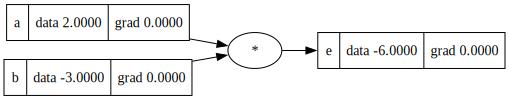

In [28]:
draw_dot(e)

In [99]:
h = 0.00001
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
print(L)


Value(data=-8.0, grad=0)


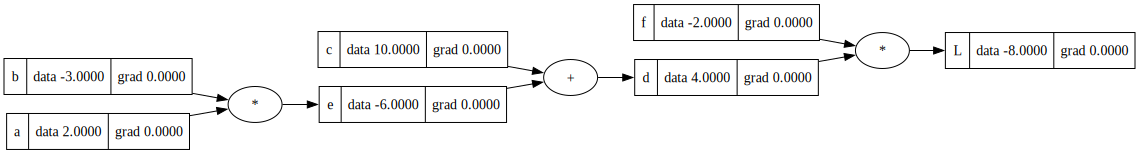

In [66]:
draw_dot(L)

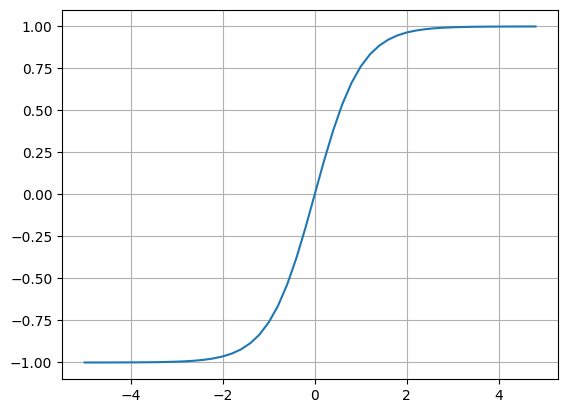

In [34]:
## ACtivation functions
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()
plt.show()

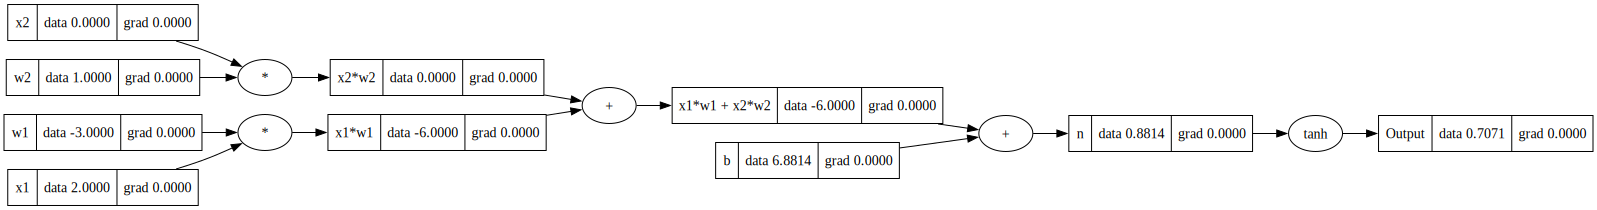

In [107]:
## A simple neuron with two weight
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()
o.label="Output"


draw_dot(o)

In [108]:
o.grad=1


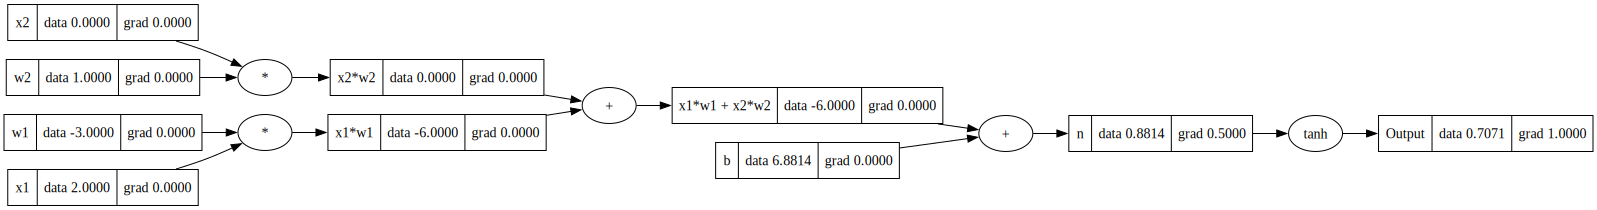

In [112]:
draw_dot(o)

In [111]:
o._backward()

In [105]:
o.grad

1